# Quantum Random Walks: A Guided Tour

> *From coin flips to coherent superposition — and why it matters for algorithms.*

---

## Section 0 — Motivation

### Why does a quantum walk need a Hadamard coin?

In a **classical random walk**, the "coin" is a stochastic matrix: at each step the walker moves left with probability ½ and right with probability ½. As a matrix acting on the probability vector $(p_L, p_R)$, the classical coin is:

$$C_{\text{classical}} = \begin{pmatrix} 1/2 & 1/2 \\ 1/2 & 1/2 \end{pmatrix}$$

Every entry has magnitude ½, so every *probability* of switching direction is ½. Fine.

In quantum mechanics, evolution must be **unitary** — probabilities are squared magnitudes, so we need a matrix $U$ where every entry has *squared* magnitude ½. That means every entry must have magnitude $1/\sqrt{2}$. What $2 \times 2$ unitary matrix achieves this?

$$C_{\text{classical}} = \begin{pmatrix} 1/2 & 1/2 \\ 1/2 & 1/2 \end{pmatrix} \qquad \longrightarrow \qquad H = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$$

The Hadamard matrix $H$ is the answer — not an arbitrary choice, but a **necessity** forced by unitarity. (Up to global phase and diagonal unitaries, it is essentially unique for a fair 2-state coin.)

### The Hilbert space

The quantum walker lives in the tensor product space:

$$\mathcal{H} = \mathcal{H}_{\text{position}} \otimes \mathcal{H}_{\text{coin}}$$

- $\mathcal{H}_{\text{position}}$: spanned by $|x\rangle$ for $x \in \mathbb{Z}$ (truncated to a finite lattice in simulation)
- $\mathcal{H}_{\text{coin}}$: a two-level system spanned by $|L\rangle = (1,0)^T$ and $|R\rangle = (0,1)^T$

The initial state is:
$$|\psi_0\rangle = |0\rangle \otimes |\chi_0\rangle$$

where $|\chi_0\rangle$ is some normalized coin state (we will explore several choices).

**Containment claim:** If you *measure* the coin at every step — collapsing the quantum state before the next coin flip — you exactly recover the classical random walk. The quantum walk is a generalization, not a replacement. We will prove this numerically in Section 7.

## Section 0.5 — One step of the walk

### The update rule

A quantum walk step consists of two operations applied in sequence:

1. **Coin flip:** apply the Hadamard to the coin state  
2. **Conditional shift:** move left or right depending on the coin

The shift operator acts on basis states as:
$$
S\,|x,L\rangle = |x-1,L\rangle, \qquad
S\,|x,R\rangle = |x+1,R\rangle
$$

So the full update rule is:
$$
|\psi_{t+1}\rangle = S \,(I \otimes H)\, |\psi_t\rangle
$$

---

### Minimal example

Start from a localized walker with a definite coin:
$$
|\psi_0\rangle = |0\rangle \otimes |R\rangle
$$

Apply the coin:
$$
(I \otimes H)|\psi_0\rangle
= \frac{1}{\sqrt{2}}\, |0\rangle \otimes (|L\rangle + |R\rangle)
$$

Then apply the shift:
$$
|\psi_1\rangle
= \frac{1}{\sqrt{2}} \big(|-1,L\rangle + |+1,R\rangle\big)
$$

---

### Interpretation

After one step, the walker is not at a single position, but in a **superposition of moving left and right**.

Crucially, these are **amplitudes**, not probabilities. Over multiple steps, contributions from different paths can combine with different signs, leading to **interference effects** that have no classical analogue.

---

## Section 1 — Theory Reference Card

*Everything below is optional background. You do not need it to follow the simulations — treat it as a dictionary to consult if something surprises you.*

| Property | Classical Random Walk | Quantum Walk |
|---|---|---|
| **Transition rule** | $p(x,t+1) = \frac{1}{2}p(x-1,t) + \frac{1}{2}p(x+1,t)$ | $\vert\psi(t+1)\rangle = S \cdot (I \otimes H)\vert\psi(t)\rangle$ |
| **Spreading law** | $\sigma(t) \sim \sqrt{t}$ (diffusive) | $\sigma(t) \sim t$ (ballistic) |
| **Limit distribution** | Gaussian (Central Limit Theorem) | Konno's arcsine distribution — two peaks at $\pm t$, suppressed center |
| **Memory** | Markov: future depends only on present | Non-Markov: all paths interfere coherently |
| **Decoherence limit** | Already classical | Recovers classical walk as decoherence → 1 |

### If you want to go deeper

- **Kempe (2003)** — The standard review of quantum walks and their algorithmic applications: [https://arxiv.org/abs/quant-ph/0303081](https://arxiv.org/abs/quant-ph/0303081)
- **Aharonov, Ambainis, Kempe, Vazirani (2001)** — Original paper on discrete-time quantum walks: [https://arxiv.org/abs/quant-ph/0012090](https://arxiv.org/abs/quant-ph/0012090)
- **Konno (2002)** — Rigorous derivation of the limit distribution: [https://arxiv.org/abs/quant-ph/0206053](https://arxiv.org/abs/quant-ph/0206053)
- **Childs et al. (2003)** — Exponential algorithmic speedup via quantum walks: [https://arxiv.org/abs/quant-ph/0209131](https://arxiv.org/abs/quant-ph/0209131)

---

## Shared Imports

Run this cell first — all sections depend on it.

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LogNorm

# Consistent plot style throughout
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

PLOT_TIMES = [20, 60, 120, 200]   # four snapshot times used throughout
T_MAX      = 200                   # total simulation length
N_WALKERS  = 5000                  # Monte Carlo walkers for classical simulation
SEED       = 42
rng        = np.random.default_rng(SEED)

print("Imports complete.")

Imports complete.


---

## Section 2 — Classical Random Walk

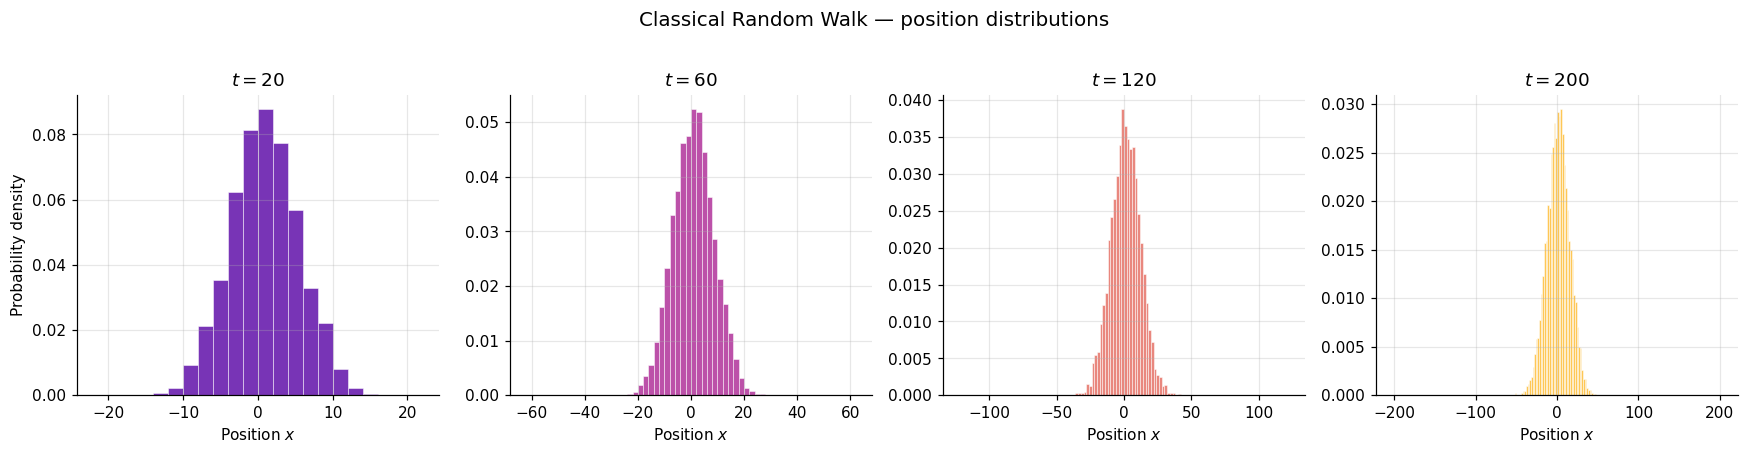

In [26]:
# ── Parameters ────────────────────────────────────────────────────────────────
p_right = 0.5   # <-- try changing this (e.g. 0.6) to introduce a drift bias

# ── Monte Carlo simulation ────────────────────────────────────────────────────
def simulate_classical_walk(n_walkers, t_max, p, rng):
    """Return position history: shape (t_max+1, n_walkers)."""
    steps = rng.random((t_max, n_walkers)) < p          # True → +1, False → -1
    steps = steps * 2 - 1                               # map to {+1, -1}
    positions = np.zeros((t_max + 1, n_walkers), dtype=int)
    positions[1:] = np.cumsum(steps, axis=0)
    return positions

classical_positions = simulate_classical_walk(N_WALKERS, T_MAX, p_right, rng)

# ── Distribution plots at four times ─────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
colors = plt.cm.plasma(np.linspace(0.15, 0.85, 4))

for ax, t, c in zip(axes, PLOT_TIMES, colors):
    bins = np.arange(-t - 2, t + 4, 2)  # only even positions are reachable
    ax.hist(classical_positions[t], bins=bins, density=True,
            color=c, alpha=0.8, edgecolor='white', linewidth=0.4)
    ax.set_title(f"$t = {t}$")
    ax.set_xlabel("Position $x$")

axes[0].set_ylabel("Probability density")
fig.suptitle("Classical Random Walk — position distributions", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Engagement question:** The shape above is a Gaussian. What theorem guarantees this, and what happens to the distribution if you set `p_right ≠ 0.5`? Try it before reading on.

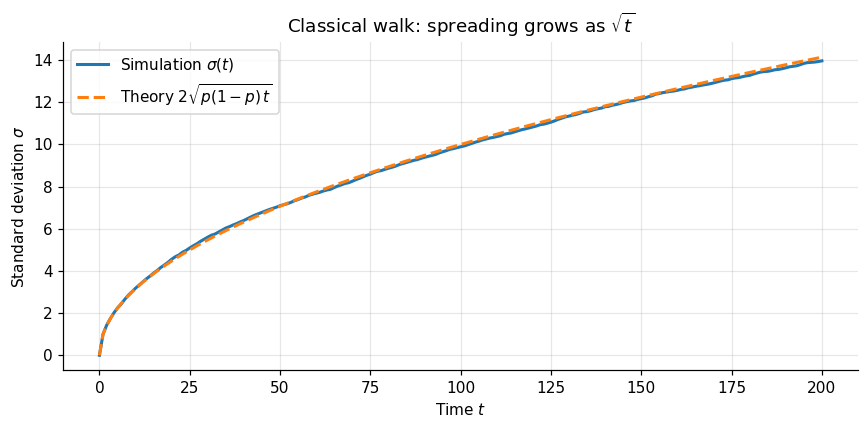

In [27]:
# ── σ(t) vs √t theory curve ───────────────────────────────────────────────────
t_vals = np.arange(T_MAX + 1)

# Empirical std from Monte Carlo
classical_std = classical_positions.std(axis=1)

# Theory: σ(t) = √(p·q·t) where q = 1-p
theory_std_classical = 2*np.sqrt(p_right * (1 - p_right) * t_vals)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_vals, classical_std, lw=2, label="Simulation $\\sigma(t)$")
ax.plot(t_vals, theory_std_classical, lw=2, ls='--',
        label=r"Theory $2\sqrt{p(1-p)\,t}$")
ax.set_xlabel("Time $t$")
ax.set_ylabel("Standard deviation $\\sigma$")
ax.set_title("Classical walk: spreading grows as $\\sqrt{t}$")
ax.legend()
plt.tight_layout()
plt.show()

---

## Section 3 — Quantum Walk Simulation

In [28]:
# ══════════════════════════════════════════════════════════════════════════════
# Core quantum walk engine  (reused in all later sections)
# ══════════════════════════════════════════════════════════════════════════════

def hadamard_coin():
    return (1 / np.sqrt(2)) * np.array([[1,  1],
                                         [1, -1]], dtype=np.complex128)

def normalize(v):
    v = np.asarray(v, dtype=np.complex128).reshape(2)
    return v / np.linalg.norm(v)

def symmetric_state():
    """(|L⟩ + i|R⟩) / √2 — gives a centred distribution."""
    return normalize([1, 1j])

def simulate_quantum_walk(
    T_max,
    coin=None,
    initial_coin_state=None,
    p_decohere=0.0,
    rng_decohere=None,
):
    """
    Simulate a 1-D discrete-time quantum walk.

    Parameters
    ----------
    T_max            : int   — number of steps
    coin             : (2,2) complex array, default Hadamard
    initial_coin_state : (2,) complex array, default (|L⟩+i|R⟩)/√2
    p_decohere       : float in [0,1] — probability of mid-step coin measurement
    rng_decohere     : numpy Generator for reproducible decoherence

    Returns
    -------
    history  : (T_max+1, 2, N_x)  amplitude tensor
    x_vals   : (N_x,)             integer lattice positions
    """
    if coin is None:
        coin = hadamard_coin()
    if initial_coin_state is None:
        initial_coin_state = symmetric_state()
    if rng_decohere is None:
        rng_decohere = np.random.default_rng(0)

    coin = np.asarray(coin, dtype=np.complex128)
    initial_coin_state = normalize(initial_coin_state)

    margin = 2
    x_vals = np.arange(-T_max - margin, T_max + margin + 1, dtype=int)
    N_x = len(x_vals)
    origin = T_max + margin

    history = np.zeros((T_max + 1, 2, N_x), dtype=np.complex128)
    history[0, :, origin] = initial_coin_state

    for t in range(T_max):
        psi = history[t]                    # (2, N_x)
        after_coin = coin @ psi             # (2, N_x)

        # Optional mid-step decoherence: measure (collapse) coin
        if p_decohere > 0:
            for j in range(N_x):
                if rng_decohere.random() < p_decohere:
                    pL = np.abs(after_coin[0, j])**2
                    pR = np.abs(after_coin[1, j])**2
                    total = pL + pR
                    if total > 0:
                        # collapse to |L⟩ or |R⟩
                        if rng_decohere.random() < pL / total:
                            after_coin[0, j] = np.sqrt(total)
                            after_coin[1, j] = 0.0
                        else:
                            after_coin[0, j] = 0.0
                            after_coin[1, j] = np.sqrt(total)

        psi_next = np.zeros_like(psi)
        psi_next[0, :-1] += after_coin[0, 1:]   # |L⟩ shifts left
        psi_next[1,  1:] += after_coin[1, :-1]  # |R⟩ shifts right
        history[t + 1] = psi_next

    return history, x_vals


def prob_history(history):
    """(T+1, N_x) probability tensor from amplitude history."""
    return np.abs(history[:, 0])**2 + np.abs(history[:, 1])**2


def std_over_time(history, x_vals):
    """Return (T+1,) array of positional standard deviations."""
    ph = prob_history(history)          # (T+1, N_x)
    means = ph @ x_vals
    second_moments = ph @ x_vals**2
    variances = second_moments - means**2
    return np.sqrt(np.maximum(variances, 0.0))


print("Quantum walk engine defined.")

Quantum walk engine defined.


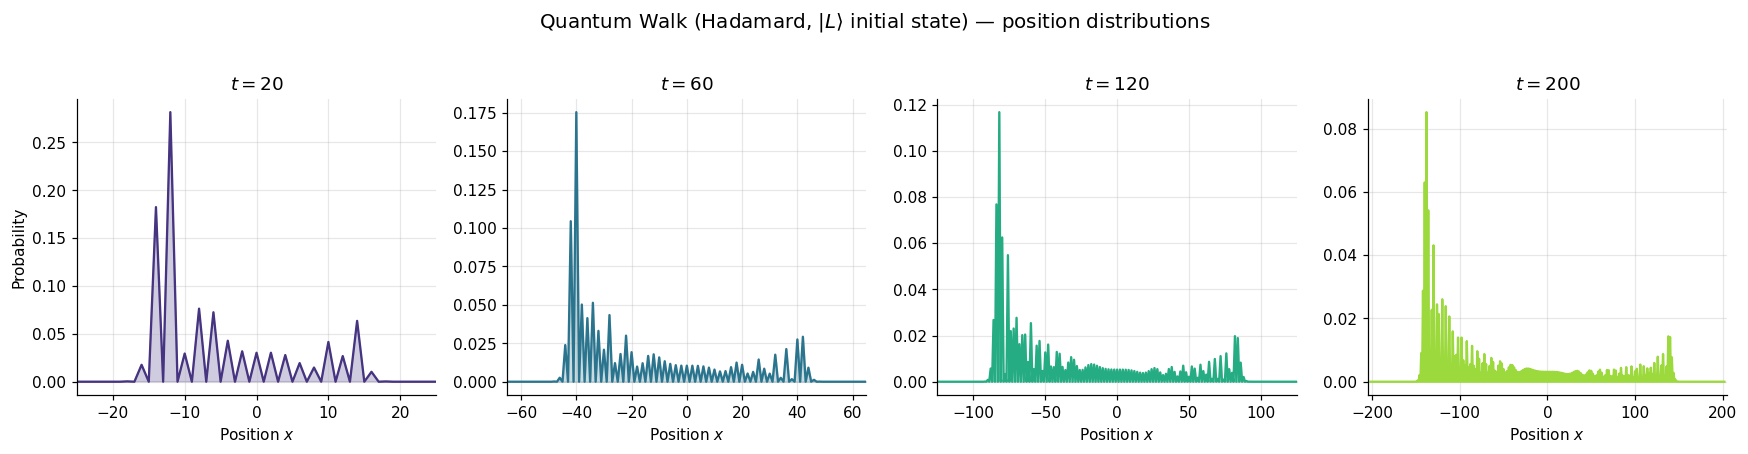

In [29]:
# ── Run with default |L⟩ initial state (shows asymmetry) ─────────────────────
history_L, x_vals = simulate_quantum_walk(
    T_MAX,
    initial_coin_state=np.array([1, 0]),   # |L⟩
)
ph_L = prob_history(history_L)

# ── Distribution plots at four times ─────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, 4))

for ax, t, c in zip(axes, PLOT_TIMES, colors):
    ax.plot(x_vals, ph_L[t], lw=1.5, color=c)
    ax.fill_between(x_vals, ph_L[t], alpha=0.25, color=c)
    ax.set_title(f"$t = {t}$")
    ax.set_xlabel("Position $x$")
    ax.set_xlim(-t - 5, t + 5)

axes[0].set_ylabel("Probability")
fig.suptitle("Quantum Walk (Hadamard, $|L\\rangle$ initial state) — position distributions",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Notice:** Two peaks emerge and move outward — nothing like the Gaussian bell curve. The distribution is *asymmetric* (the left peak is taller) because we started in $|L\rangle$.

**Engagement question:** Before running the next section, predict: what will the distribution look like if you start in $|R\rangle$? What about $(|L\rangle + i|R\rangle)/\sqrt{2}$? Make a prediction, then check in Section 5.

---

## Section 4 — Direct Comparison

**The one number to remember:** quantum spreading is *linear* in time ($\sigma \sim t/\sqrt{2}$); classical spreading is *square-root* ($\sigma \sim \sqrt{t}$). At $t = 200$, the quantum walker is roughly $\sqrt{200} \approx 14\times$ more spread out than its classical counterpart.

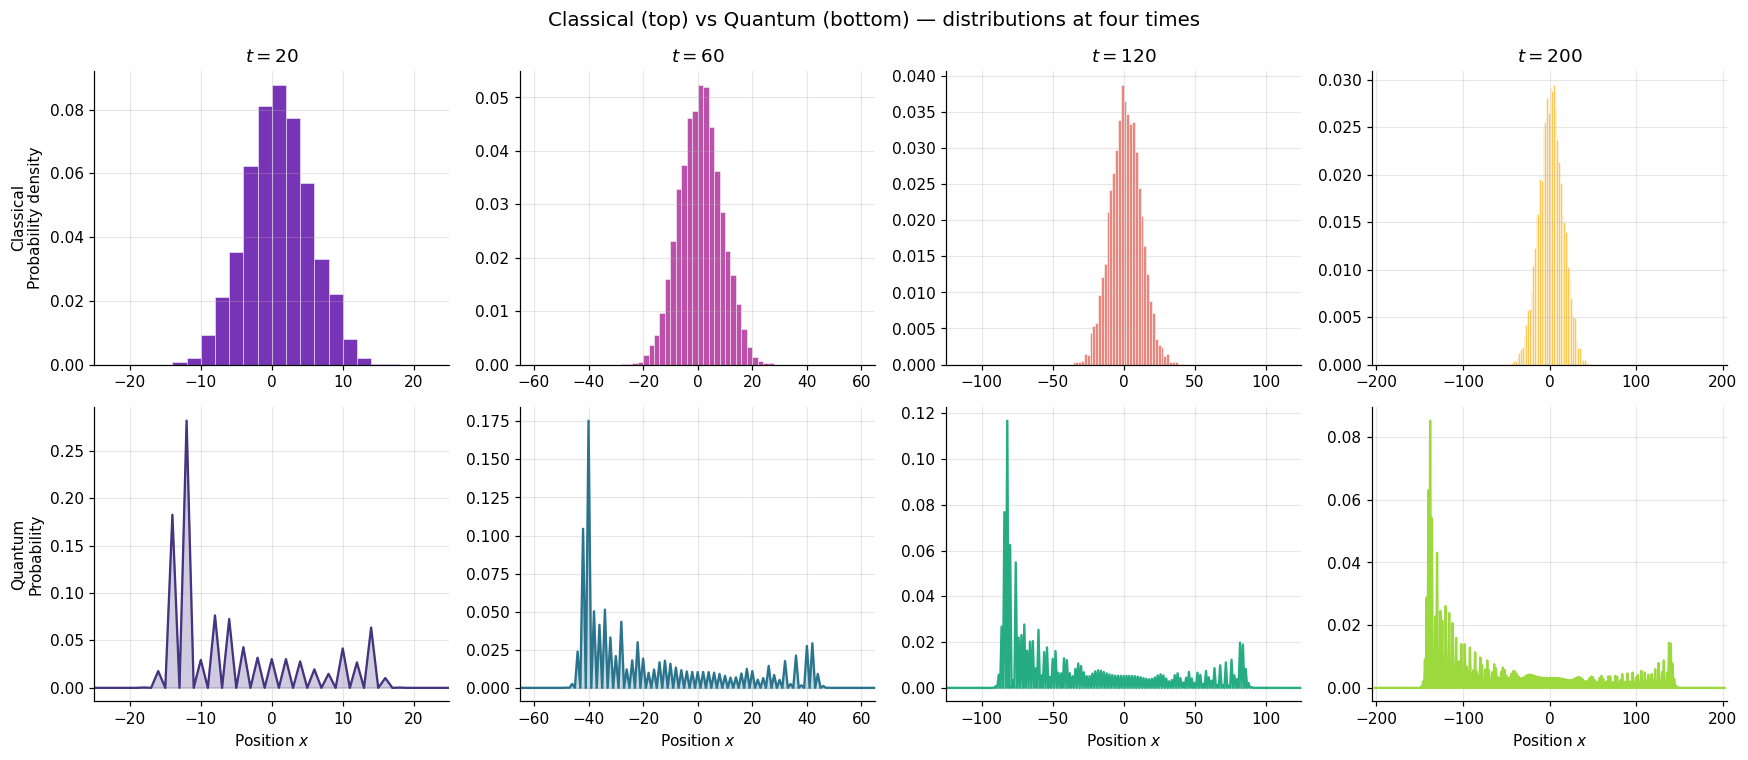

In [30]:
# ── Fig 1: distributions side by side at four snapshot times ─────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
cmap_c = plt.cm.plasma
cmap_q = plt.cm.viridis

for col, t in enumerate(PLOT_TIMES):
    c_col = cmap_c(0.15 + 0.7 * col / 3)
    q_col = cmap_q(0.15 + 0.7 * col / 3)

    # Classical (top row)
    bins = np.arange(-t - 2, t + 4, 2)
    axes[0, col].hist(classical_positions[t], bins=bins, density=True,
                     color=c_col, alpha=0.8, edgecolor='white', lw=0.4)
    axes[0, col].set_title(f"$t = {t}$")
    axes[0, col].set_xlim(-t - 5, t + 5)

    # Quantum (bottom row)
    axes[1, col].plot(x_vals, ph_L[t], lw=1.5, color=q_col)
    axes[1, col].fill_between(x_vals, ph_L[t], alpha=0.25, color=q_col)
    axes[1, col].set_xlim(-t - 5, t + 5)
    axes[1, col].set_xlabel("Position $x$")

axes[0, 0].set_ylabel("Classical\nProbability density")
axes[1, 0].set_ylabel("Quantum\nProbability")
fig.suptitle("Classical (top) vs Quantum (bottom) — distributions at four times",
             fontsize=13)
plt.tight_layout()
plt.show()

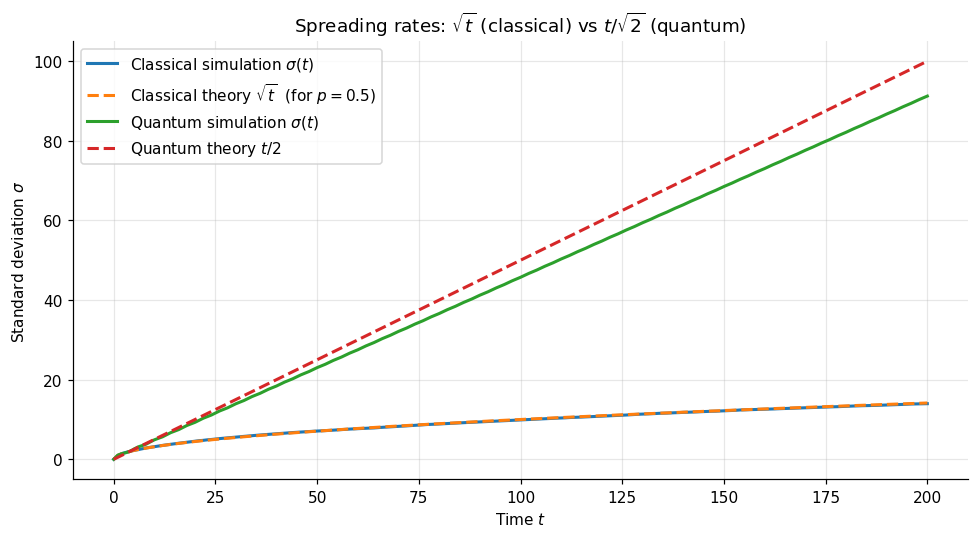

In [31]:
# ── Fig 2: σ(t) — the central quantitative result ─────────────────────────────
t_vals = np.arange(T_MAX + 1)

quantum_std = std_over_time(history_L, x_vals)
theory_quantum_std = t_vals / 2

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t_vals, classical_std,     lw=2,   label="Classical simulation $\\sigma(t)$")
ax.plot(t_vals, theory_std_classical, lw=2, ls='--',
        label=r"Classical theory $\sqrt{t}$  (for $p=0.5$)")
ax.plot(t_vals, quantum_std,       lw=2,   label="Quantum simulation $\\sigma(t)$")
ax.plot(t_vals, theory_quantum_std, lw=2,  ls='--',
        label=r"Quantum theory $t/2$")

ax.set_xlabel("Time $t$")
ax.set_ylabel("Standard deviation $\\sigma$")
ax.set_title("Spreading rates: $\\sqrt{t}$ (classical) vs $t/\\sqrt{2}$ (quantum)")
ax.legend()
plt.tight_layout()
plt.show()

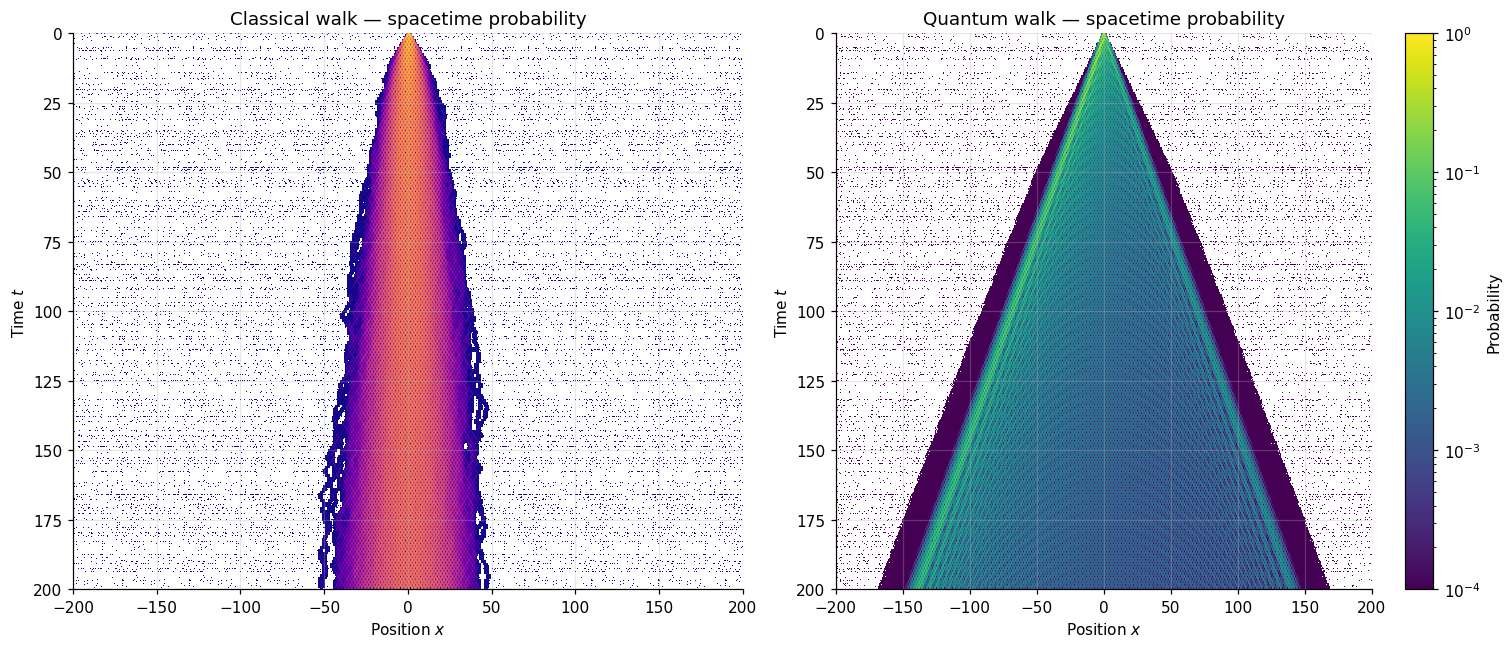

In [32]:
# ── Fig 3: spacetime heatmaps ─────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Classical heatmap — build from histogram
xbins = np.arange(-T_MAX - 1, T_MAX + 2)
classical_heatmap = np.zeros((T_MAX + 1, len(xbins) - 1))
for t in range(T_MAX + 1):
    counts, _ = np.histogram(classical_positions[t], bins=xbins)
    classical_heatmap[t] = counts / counts.sum()

ax1.imshow(classical_heatmap, aspect='auto', cmap='plasma',
           extent=[xbins[0], xbins[-1], T_MAX, 0],
           norm=LogNorm(vmin=1e-4, vmax=1))
ax1.set_xlabel("Position $x$")
ax1.set_ylabel("Time $t$")
ax1.set_title("Classical walk — spacetime probability")
ax1.set_xlim(-T_MAX, T_MAX)

# Quantum heatmap
extent_q = [x_vals[0] - 0.5, x_vals[-1] + 0.5, T_MAX, 0]
im = ax2.imshow(ph_L, aspect='auto', cmap='viridis', extent=extent_q, norm=LogNorm(vmin=1e-4, vmax=1))
ax2.set_xlabel("Position $x$")
ax2.set_ylabel("Time $t$")
ax2.set_title("Quantum walk — spacetime probability")
ax2.set_xlim(-T_MAX, T_MAX)
plt.colorbar(im, ax=ax2, label="Probability")

plt.tight_layout()
plt.show()

The heatmap makes the spreading difference visceral: the classical walker fills a triangular cone slowly (diffusion), while the quantum walker's two bright "wavefronts" shoot out at nearly the speed limit $|x| \leq t$ (ballistic propagation).

---

## Section 5 — Role of the Initial Coin State

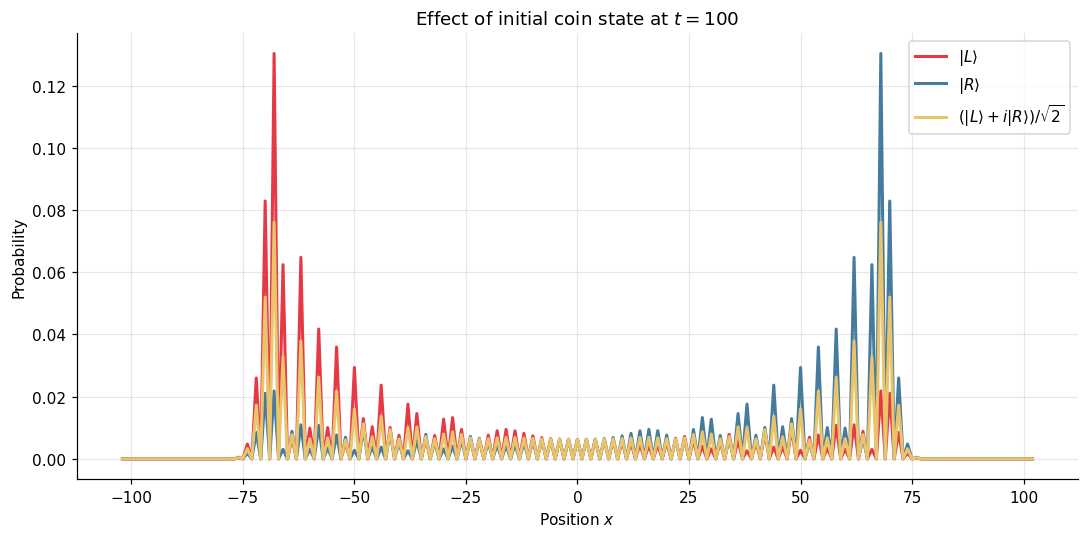

In [19]:
T_COIN = 100

coin_states = {
    r"$|L\rangle$":                          np.array([1, 0]),
    r"$|R\rangle$":                          np.array([0, 1]),
    r"$(|L\rangle + i|R\rangle)/\sqrt{2}$": np.array([1, 1j]) / np.sqrt(2),
}

# Run walks
results_coin = {}
for label, state in coin_states.items():
    h, xv = simulate_quantum_walk(T_COIN, initial_coin_state=state)
    results_coin[label] = (h, xv)

# ── Overlay distributions at t=100 ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colors_coin = ['#e63946', '#457b9d', '#e9c46a']

for (label, (h, xv)), c in zip(results_coin.items(), colors_coin):
    ph = prob_history(h)
    ax.plot(xv, ph[T_COIN], lw=2, label=label, color=c)

ax.set_xlabel("Position $x$")
ax.set_ylabel("Probability")
ax.set_title(f"Effect of initial coin state at $t = {T_COIN}$")
ax.legend()
plt.tight_layout()
plt.show()

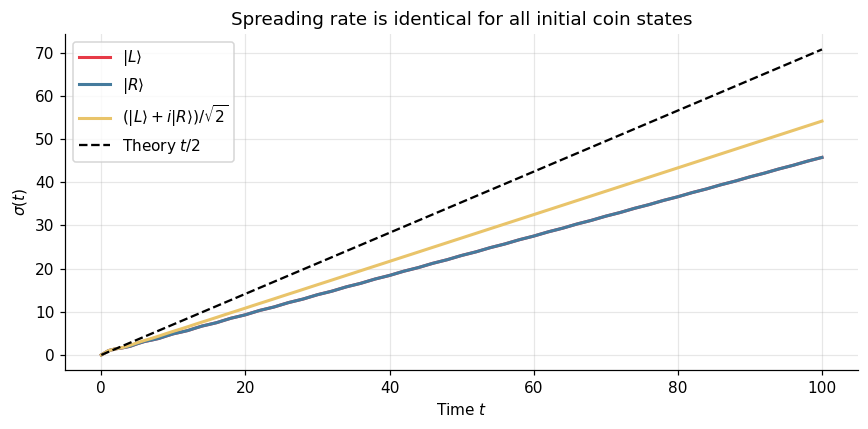

In [20]:
# ── σ(t) for all three initial states ────────────────────────────────────────
t_vals_coin = np.arange(T_COIN + 1)

fig, ax = plt.subplots(figsize=(8, 4))
for (label, (h, xv)), c in zip(results_coin.items(), colors_coin):
    ax.plot(t_vals_coin, std_over_time(h, xv), lw=2, label=label, color=c)

ax.plot(t_vals_coin, t_vals_coin / np.sqrt(2), 'k--', lw=1.5,
        label=r"Theory $t/2$")
ax.set_xlabel("Time $t$")
ax.set_ylabel("$\\sigma(t)$")
ax.set_title("Spreading rate is identical for all initial coin states")
ax.legend()
plt.tight_layout()
plt.show()

**Key observation:** $|L\rangle$ and $|R\rangle$ give mirror-image asymmetric distributions; the symmetric state $(|L\rangle + i|R\rangle)/\sqrt{2}$ gives a centred, symmetric one. But all three spread at *exactly* the same rate $\sigma \sim t/2$.

**Engagement question:** The coin state controls the *shape* of the distribution but not the spreading *rate*. What does this tell you about what is fundamentally "quantum" in the walk — is it the specific coin state, or the *coherence* (interference between paths) maintained throughout the evolution?

---

## Section 6 — Decoherence: From Quantum to Classical

At each timestep, with probability $p_{\text{dec}}$ we *measure* (collapse) the coin before applying the shift. This destroys superposition at that site.

- $p_{\text{dec}} = 0$: pure quantum walk
- $p_{\text{dec}} = 1$: full measurement every step → classical walk

The intermediate cases continuously interpolate between the two regimes.

In [23]:
T_DEC = 150
p_dec_values = [0.0, 0.01, 0.1, 0.5, 1.0]
n_ensembles = 200  

results_dec = {}

for p in p_dec_values:
    avg_h = None
    rng_decohere = np.random.default_rng(7) 
    
    for _ in range(n_ensembles):
        h_raw, xv = simulate_quantum_walk(
            T_DEC,
            initial_coin_state=symmetric_state(),
            p_decohere=p,
            rng_decohere=rng_decohere, 
        )
        
        # Assuming prob_history extracts the full 2D probability matrix (time x position)
        h_prob = prob_history(h_raw) 
        
        if avg_h is None:
            avg_h = np.zeros_like(h_prob)
            
        avg_h += h_prob
        
    avg_h = avg_h / n_ensembles
    
    # Store the averaged 2D history
    results_dec[p] = (avg_h, xv)

print("Decoherence sweep complete.")

Decoherence sweep complete.


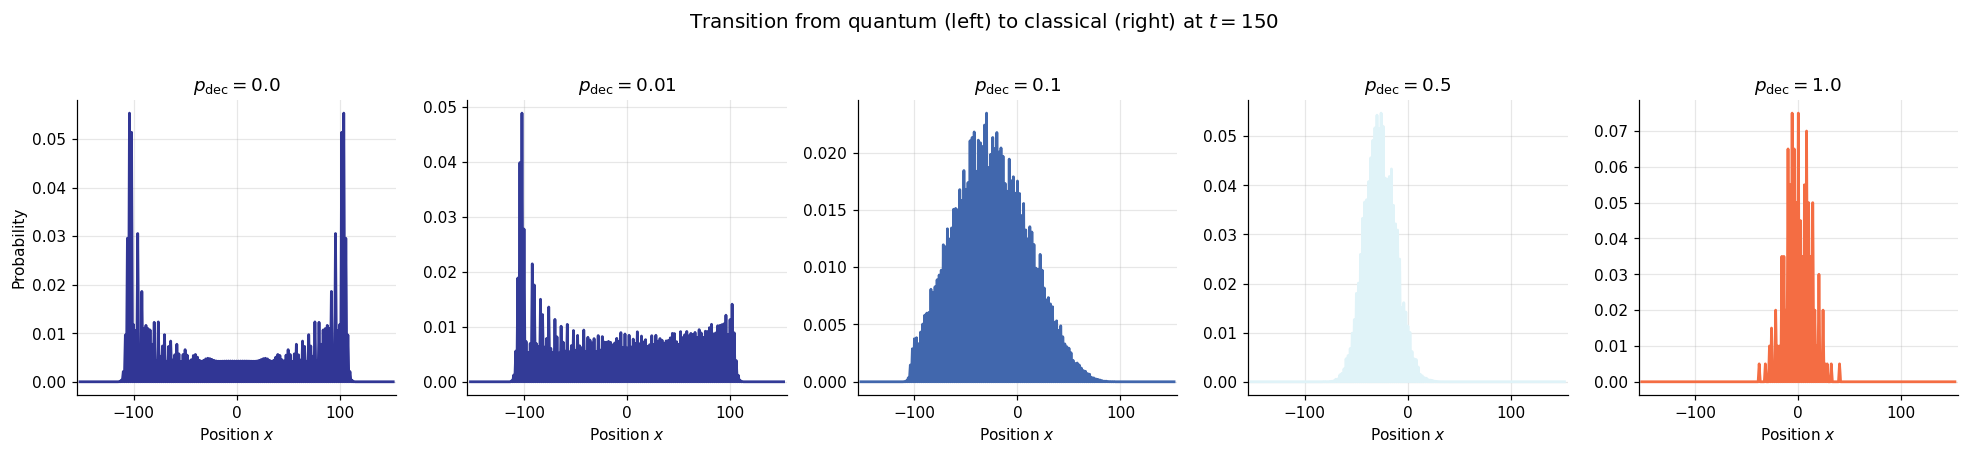

In [24]:
# ── Distribution plots at t = T_DEC ───────────────────────────────────────────
fig, axes = plt.subplots(1, len(p_dec_values), figsize=(18, 4), sharey=False)
cmap_dec = plt.cm.RdYlBu

for ax, p in zip(axes, p_dec_values):
    ph, xv = results_dec[p]
    c = cmap_dec(1 - p * 0.8)
    ax.plot(xv, ph[T_DEC], lw=1.8, color=c)
    ax.fill_between(xv, ph[T_DEC], alpha=0.3, color=c)
    ax.set_title(f"$p_{{\\text{{dec}}}} = {p}$")
    ax.set_xlabel("Position $x$")
    ax.set_xlim(-T_DEC - 5, T_DEC + 5)

axes[0].set_ylabel("Probability")
fig.suptitle(f"Transition from quantum (left) to classical (right) at $t = {T_DEC}$",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

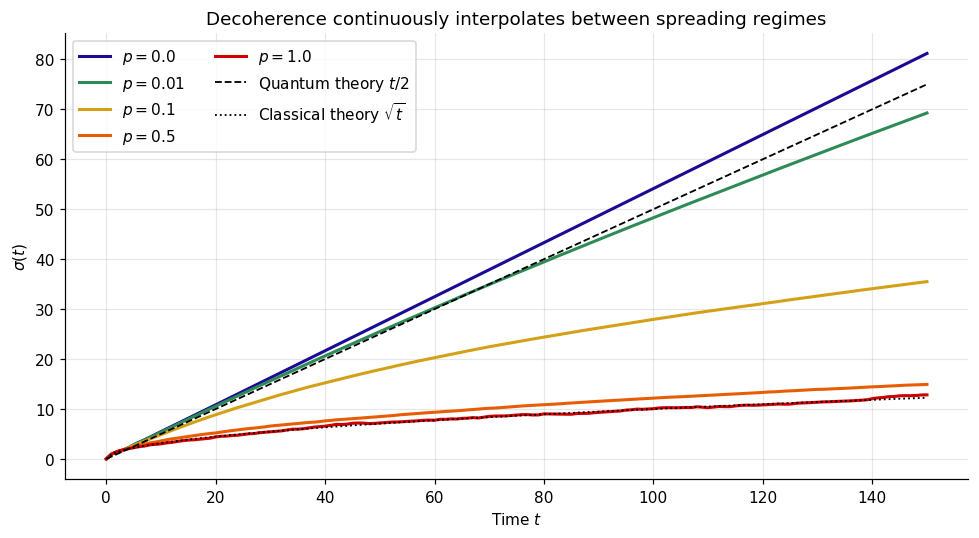

In [35]:
# ── σ(t) sweep ────────────────────────────────────────────────────────────────
t_dec = np.arange(T_DEC + 1)

dec_colors = {
    0.0:  '#1a0a94',   # deep blue (pure quantum)
    0.01: '#2e8b57',   # green
    0.1:  '#d4a017',   # gold
    0.5:  '#e85d04',   # orange
    1.0:  '#d00000',   # red (fully classical)
}

fig, ax = plt.subplots(figsize=(9, 5))
for p in p_dec_values:
    ph, xv = results_dec[p] # ph is ALREADY the probability history!
    c = dec_colors[p]
    
    # Calculate std directly since ph is already probabilities
    means = ph @ xv
    second_moments = ph @ (xv**2)
    stds = np.sqrt(second_moments - means**2)
    
    ax.plot(t_dec, stds, lw=2, label=f"$p = {p}$", color=c)

ax.plot(t_dec, t_dec / 2, 'k--', lw=1.2, label=r"Quantum theory $t/2$")
ax.plot(t_dec, np.sqrt(t_dec), 'k:',  lw=1.2, label=r"Classical theory $\sqrt{t}$")
ax.set_xlabel("Time $t$")
ax.set_ylabel("$\\sigma(t)$")
ax.set_title("Decoherence continuously interpolates between spreading regimes")
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

This is the **proof of containment** from Section 0, now visible: full decoherence ($p = 1$) reproduces the classical $\sqrt{t}$ spreading exactly. Even modest decoherence ($p = 0.1$) substantially degrades the quantum advantage.

**Engagement question:** At what decoherence rate does the walk start looking classical *by eye* in the distribution plots? At what rate does the $\sigma(t)$ curve cross over? Are these the same threshold?

---

## Section 8 — Discussion & Takeaways

### For everyone

A classical walker forgets its history at each step — the next move depends only on where it is *now* (Markov property). A quantum walker retains *all* paths simultaneously in superposition, and those paths interfere: constructively at the wavefronts (the two peaks), destructively in the middle. This coherent interference is what drives the faster spreading.

Decoherence — the walker's entanglement with an unmonitored environment — continuously destroys this interference. Each measurement collapses the coin state, erasing the memory of which path was taken. As decoherence approaches certainty, the quantum walk smoothly recovers classical diffusion. This is why we do not observe quantum walks in everyday life: any macroscopic system is constantly being "measured" by its thermal environment.

---

### For CS / algorithms readers

The spreading law $\sigma \sim t$ is a quadratic speedup in disguise. In a search problem over $N$ items, the classical random walk takes $O(N)$ steps to find a marked item; the quantum walk takes $O(\sqrt{N})$. This is exactly Grover's algorithm — and Grover *is* a quantum walk on the hypercube.

More broadly:
- **Grover search** ($O(\sqrt{N})$ vs $O(N)$): quantum walk on the complete graph
- **Element distinctness** ($O(N^{2/3})$ vs $O(N)$): Ambainis's quantum walk algorithm
- **Graph traversal and formula evaluation**: Childs et al. (2003) showed an *exponential* speedup on certain graph problems

The spreading rate of the walk *is* the algorithmic complexity.

---

### For physics readers

The 1-D discrete quantum walk is the **Feynman checkerboard** — a discretization of the 1-D Dirac equation. The coin operator plays the role of the mass term: it mixes the left- and right-moving components at each lattice site, which is exactly the structure of the Dirac spinor. In the continuum limit, the quantum walk converges to the massless (or massive, depending on the coin) Dirac equation.

Classical diffusion is then interpretable as the zero-coherence limit of this relativistic quantum system.

**Natural next question — Anderson localization:** Add *disorder* to the lattice (random site energies or random coin angles). What happens to the ballistic spreading? In 1-D, any disorder localizes all eigenstates; the walk transitions from ballistic to *localized* (exponentially decaying probability away from the origin). This is the quantum analogue of a diffusion-to-localization transition and is an active area of quantum simulation research.